<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_14149/2120607162.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


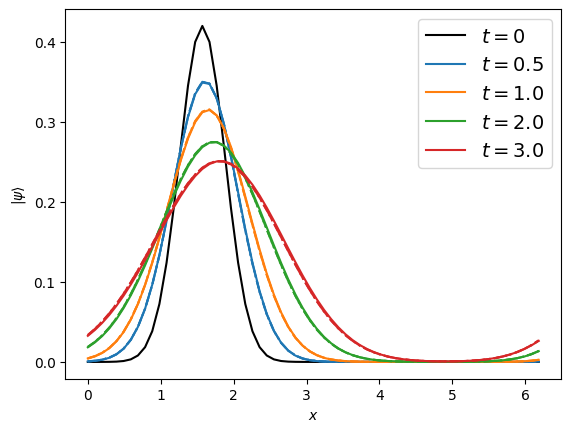

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm
from lchs import spectral_diff_adv, fe_fd_diff_adv, be_fd_diff_adv

n_qubits = 6

D = 0.1
N = 2**n_qubits
L = 2 * np.pi               
t = 0.4   
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.1
#c = c_H*np.ones_like(x)
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
#cx = np.zeros_like(x)
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

ts = [0.5, 1.0, 2.0, 3.0]

plt.figure()
plt.plot(x, state, 'k-', label='$t=0$',)
errs = []

for t in ts:
    fd_be = be_fd_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)
    fd_fe = fe_fd_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)
    spectral = spectral_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)


    line, = plt.plot(x, np.real(fd_fe), '--', markersize=4)
    color = line.get_color()
    plt.plot(x, np.real(spectral), '-', color=color, label=f'$t={t:.1f}$', )
    plt.plot(x, np.real(fd_be), '-.', color=color )
plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend(loc='best', fontsize=14)
#plt.savefig('./figures/lcu_kernel_lchs_diffusion.pdf', bbox_inches='tight')
plt.show()





<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_14149/750559252.py:49: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


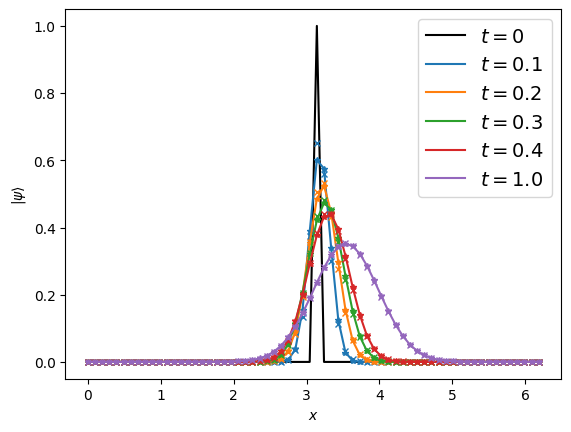

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm
from lchs import spectral_diff_adv, fe_fd_diff_adv, be_fd_diff_adv

n_qubits = 6

D = 0.1
N = 2**n_qubits
L = 2 * np.pi               
t = 0.4   
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.4
c = c_H*np.ones_like(x)
cx = np.zeros_like(x)

# Initial State: Gaussian centered in the middle

state = np.zeros_like(x)
x_0 = dx * N/2
state[N//2] = 1.0
state = state / np.linalg.norm(state)

ts = [0.1, 0.2, 0.3, 0.4, 1.0]

plt.figure()
plt.plot(x, state, 'k-', label='$t=0$',)
errs = []

for t in ts:
    spectral = spectral_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)
    fd = fe_fd_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)
    exact = np.exp(-(x-(x_0+c_H*t))**2/(4*D*t))
    exact = exact / np.linalg.norm(exact)
    
    line, = plt.plot(x, np.real(spectral), '*', markersize=4)
    color = line.get_color()
    plt.plot(x, fd, 'x', color=color, markersize=4)
    plt.plot(x, exact, '-', color=color, label=f'$t={t:.1f}$', )

plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend(loc='best', fontsize=14)
#plt.savefig('./figures/lcu_kernel_lchs_diffusion.pdf', bbox_inches='tight')
plt.show()



